In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 1. Load dataset

In [2]:
# For Kaggle:
# DATA_PATH = "/kaggle/input/240000-household-electricity-consumption-records/household_power_consumption.csv"
# For local:
DATA_PATH = "household_power_consumption.csv"

df = pd.read_csv(DATA_PATH)

# 2. Basic cleaning and timestamp construction

C:\Users\shank\AppData\Local\Temp\ipykernel_10084\4060659111.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')


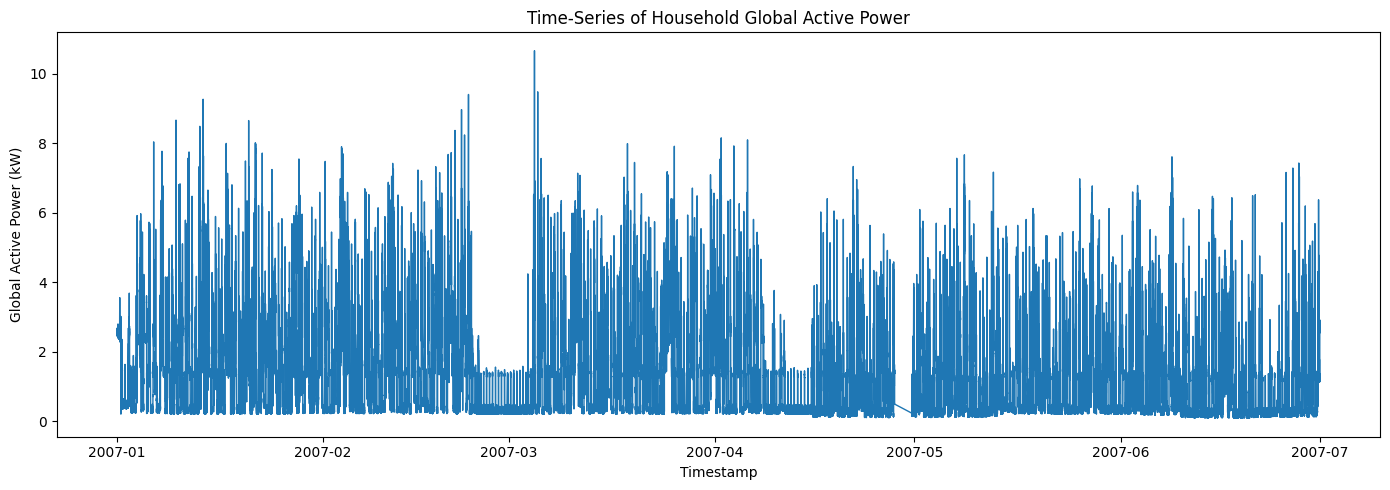

In [3]:
# Some versions have an 'index' column; drop if present
if 'index' in df.columns:
    df = df.drop(columns=['index'])

# Combine Date + Time -> Timestamp
# In this dataset Date is like '1/1/07' or '16/12/2006'
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True, errors='coerce')

# Drop rows where Timestamp could not be parsed
df = df.dropna(subset=['Timestamp'])

# Sort chronologically
df = df.sort_values('Timestamp')

# Convert numeric columns from object to float
num_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing target values
df = df.dropna(subset=['Global_active_power'])

# Figure 2 – Time-Series of Raw Power Consumption
plt.figure(figsize=(14, 5))
plt.plot(df['Timestamp'], df['Global_active_power'],
         color='tab:blue', linewidth=1)
plt.title("Time-Series of Household Global Active Power")
plt.xlabel("Timestamp")
plt.ylabel("Global Active Power (kW)")
plt.tight_layout()
plt.show()


# 3. Feature engineering

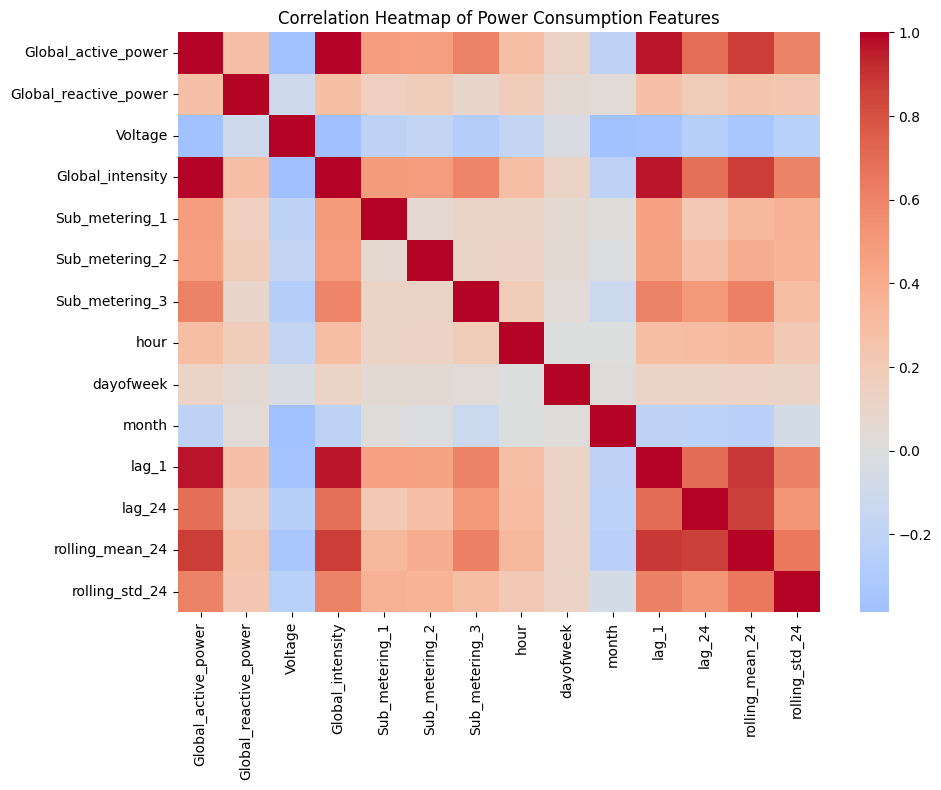

In [4]:
# Time-based features
df['hour'] = df['Timestamp'].dt.hour
df['dayofweek'] = df['Timestamp'].dt.dayofweek
df['month'] = df['Timestamp'].dt.month

# Lag features of the target (Global_active_power)
df['lag_1'] = df['Global_active_power'].shift(1)      # previous hour
df['lag_24'] = df['Global_active_power'].shift(24)    # same hour previous day

# Rolling statistics
df['rolling_mean_24'] = df['Global_active_power'].rolling(window=24).mean()
df['rolling_std_24'] = df['Global_active_power'].rolling(window=24).std()

# Drop initial rows with NaNs from lags/rolling
df = df.dropna()

# Figure 3 – Correlation Heatmap of Features
corr_features = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    'hour',
    'dayofweek',
    'month',
    'lag_1',
    'lag_24',
    'rolling_mean_24',
    'rolling_std_24'
]

corr = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Power Consumption Features")
plt.tight_layout()
plt.show()

# 4. Define features and target

In [5]:
feature_cols = [
    'hour', 'dayofweek', 'month',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    'lag_1',
    'lag_24',
    'rolling_mean_24',
    'rolling_std_24'
]

X = df[feature_cols]
y = df['Global_active_power']

# 5. Temporal train–test split (80% train, 20% test)

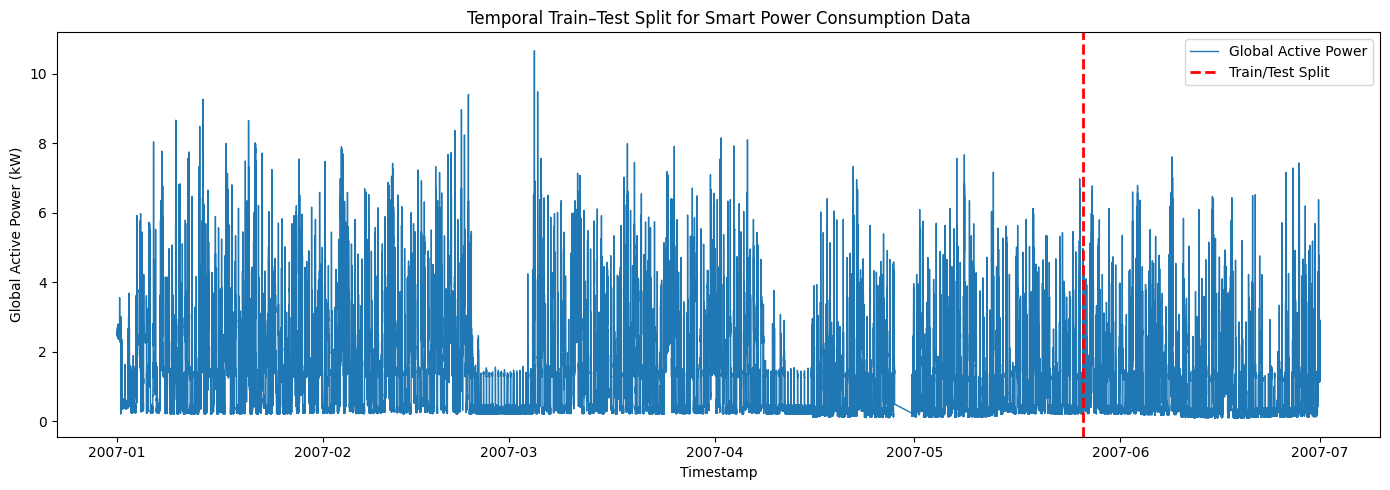

In [6]:
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

plt.figure(figsize=(14, 5))
plt.plot(df['Timestamp'], df['Global_active_power'],
         label='Global Active Power', color='tab:blue', linewidth=1)

split_time = df['Timestamp'].iloc[split_index]
plt.axvline(split_time, color='red', linestyle='--', linewidth=2,
            label='Train/Test Split')

# Figure 4 – Temporal Train–Test Split
plt.title("Temporal Train–Test Split for Smart Power Consumption Data")
plt.xlabel("Timestamp")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

# 6. Scale selected numerical features (mainly for Linear Regression)

In [7]:
scaler = StandardScaler()
# choose continuous numeric features (avoid hour/day/month as they are categorical-like)
scale_cols = [
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    'lag_1',
    'lag_24',
    'rolling_mean_24',
    'rolling_std_24'
]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

# 7. Define models

In [8]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# 8. Train and evaluate

In [19]:
# 8. Train and evaluate

results = {}
trained_models = {}

for name, model in models.items():
    # Use scaled features for all; trees don't need scaling but it's fine
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }



# 9. Display results as a DataFrame

In [10]:
results_df = pd.DataFrame(results).T
print("Evaluation metrics on test set:")
print(results_df)

Evaluation metrics on test set:
                       MAE      RMSE        R2
LinearRegression  0.028151  0.044123  0.997924
RandomForest      0.015621  0.031468  0.998944
GradientBoosting  0.019537  0.031964  0.998910


# 10. Save predictions for plotting in your notebook / report

✅ Saved smart_power_predictions.csv with actual, final, and individual model predictions.


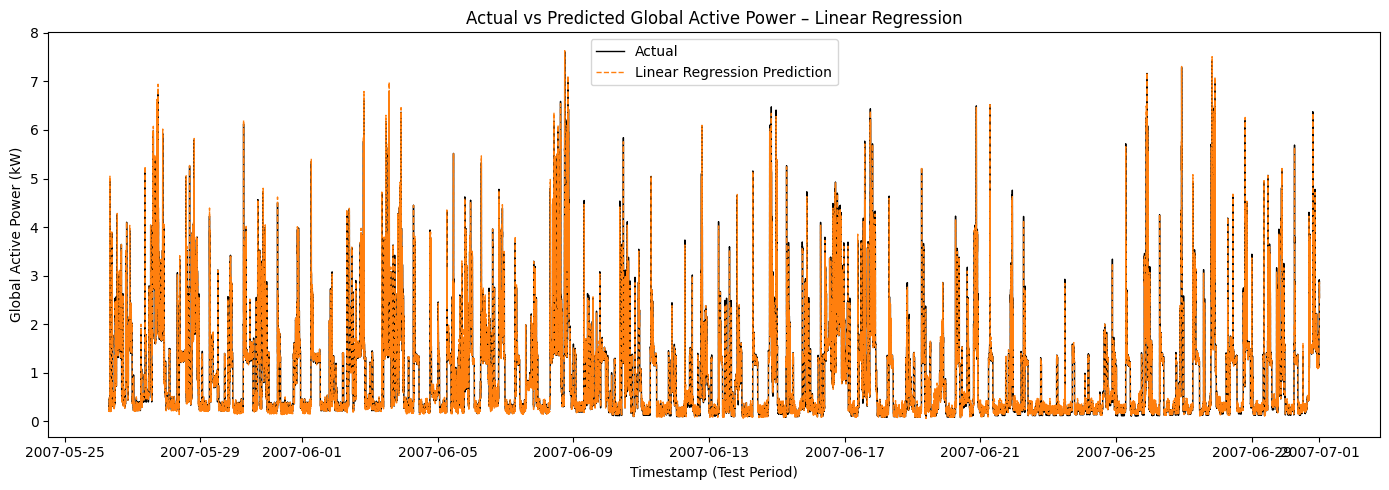

In [20]:
# Calculate predictions from each model
pred_LR = models['LinearRegression'].predict(X_test_scaled)
pred_RF = models['RandomForest'].predict(X_test_scaled)
pred_GB = models['GradientBoosting'].predict(X_test_scaled)

# Calculate ensemble prediction (average of all 3 models)
final_prediction = (pred_LR + pred_RF + pred_GB) / 3

# Create DataFrame with all predictions including Final_Prediction
predictions = pd.DataFrame({
    'Timestamp': df['Timestamp'].iloc[split_index:],
    'actual_Global_active_power': y_test.values,
    'Final_Prediction': final_prediction,  # ← NEW: Combined prediction
    'pred_LR': pred_LR,                     # ← KEPT: Linear Regression
    'pred_RF': pred_RF,                     # ← KEPT: Random Forest
    'pred_GB': pred_GB                      # ← KEPT: Gradient Boosting
})

predictions.to_csv('smart_power_predictions.csv', index=False)
print("✅ Saved smart_power_predictions.csv with actual, final, and individual model predictions.")


### Figure 5 – Actual vs Predicted Power Consumption (Linear Regression)
plt.figure(figsize=(14, 5))

plt.plot(predictions['Timestamp'],
         predictions['actual_Global_active_power'],
         label='Actual', color='black', linewidth=1)

plt.plot(predictions['Timestamp'],
         predictions['pred_LR'],
         label='Linear Regression Prediction',
         color='tab:orange', linestyle='--', linewidth=1)

plt.title("Actual vs Predicted Global Active Power – Linear Regression")
plt.xlabel("Timestamp (Test Period)")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

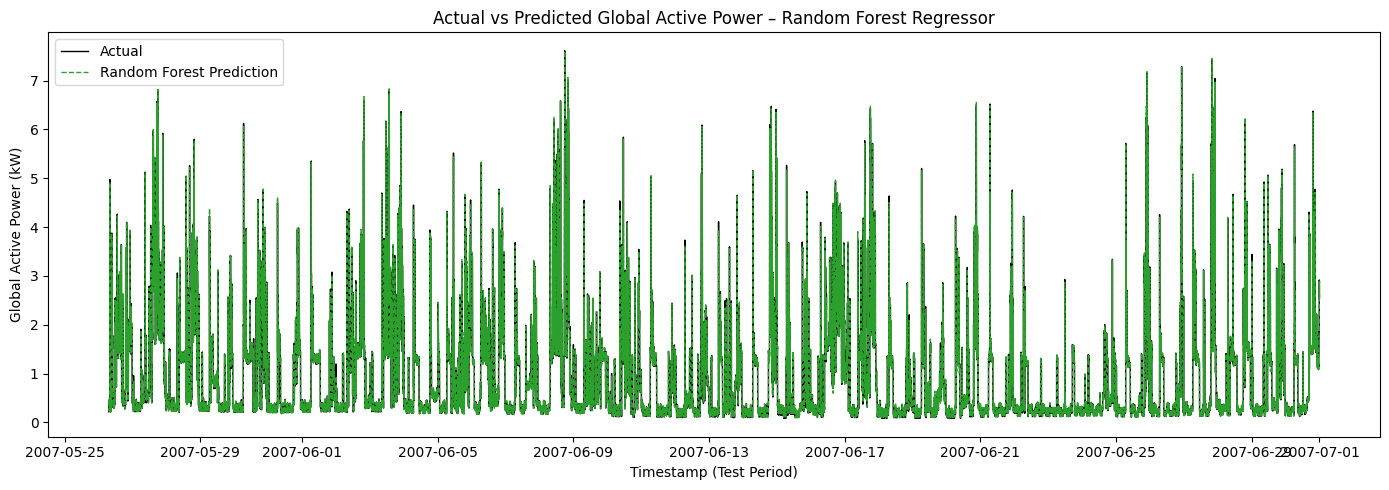

In [12]:
# Figure 6 – Actual vs Predicted Power Consumption (Random Forest)
plt.figure(figsize=(14, 5))

plt.plot(predictions['Timestamp'],
         predictions['actual_Global_active_power'],
         label='Actual', color='black', linewidth=1)

plt.plot(predictions['Timestamp'],
         predictions['pred_RF'],
         label='Random Forest Prediction',
         color='tab:green', linestyle='--', linewidth=1)

plt.title("Actual vs Predicted Global Active Power – Random Forest Regressor")
plt.xlabel("Timestamp (Test Period)")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

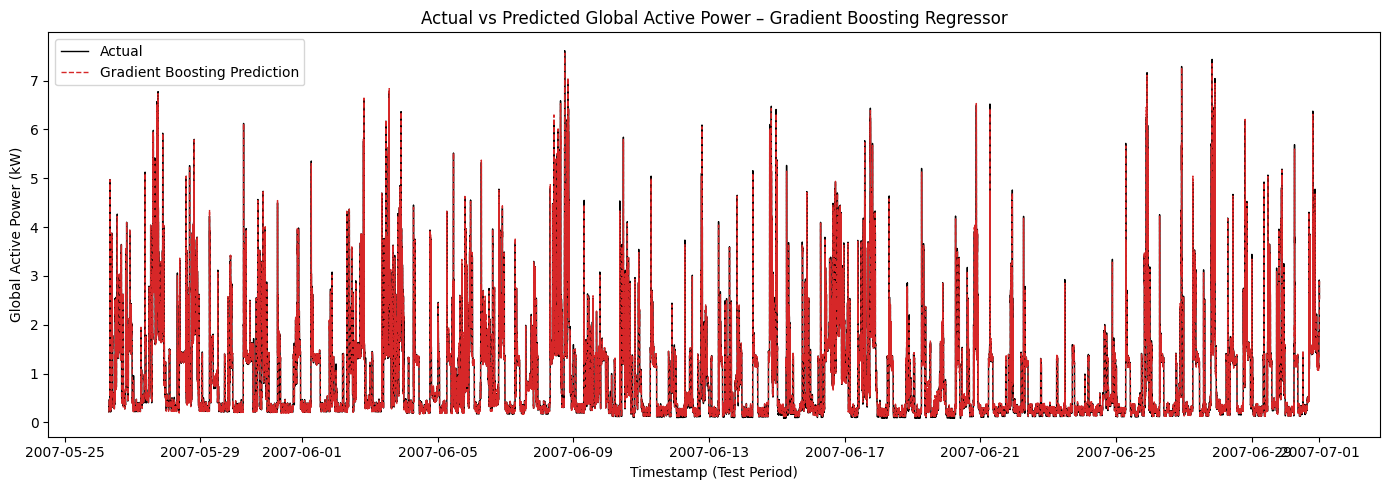

In [13]:
# Figure 7 – Actual vs Predicted Power Consumption (Gradient Boosting)
plt.figure(figsize=(14, 5))

plt.plot(predictions['Timestamp'],
         predictions['actual_Global_active_power'],
         label='Actual', color='black', linewidth=1)

plt.plot(predictions['Timestamp'],
         predictions['pred_GB'],
         label='Gradient Boosting Prediction',
         color='tab:red', linestyle='--', linewidth=1)

plt.title("Actual vs Predicted Global Active Power – Gradient Boosting Regressor")
plt.xlabel("Timestamp (Test Period)")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()

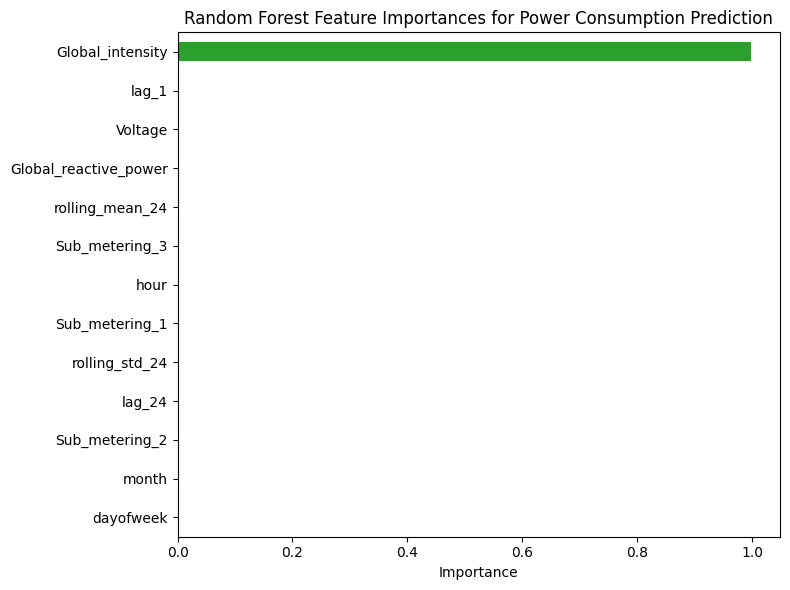

In [14]:
# Figure 8 – Feature Importances (Random Forest Regressor)
rf_model = trained_models['RandomForest']
importances_rf = rf_model.feature_importances_

fi_rf = pd.Series(importances_rf, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
fi_rf.plot(kind='barh', color='tab:green')
plt.title("Random Forest Feature Importances for Power Consumption Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

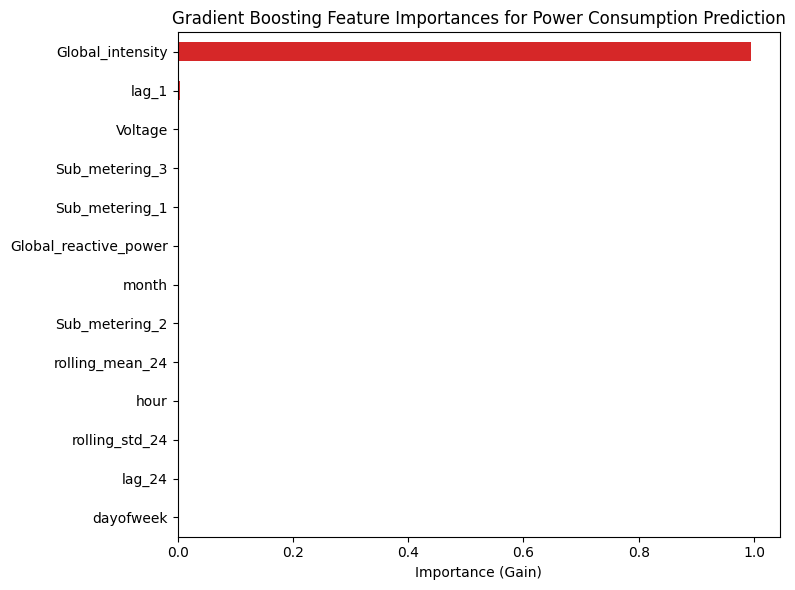

In [15]:
# Figure 9 – Feature Importances (Gradient Boosting Regressor)
gb_model = trained_models['GradientBoosting']
importances_gb = gb_model.feature_importances_

fi_gb = pd.Series(importances_gb, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
fi_gb.plot(kind='barh', color='tab:red')
plt.title("Gradient Boosting Feature Importances for Power Consumption Prediction")
plt.xlabel("Importance (Gain)")
plt.tight_layout()
plt.show()